## Setting up data

In [56]:
import pandas as pd
from data_cleaning.parse_exhibitors import parse_exhibitor_data

# load raw csvs
exhibitors = pd.read_csv("../source/exhibitors.csv")
categories = pd.read_csv("../source/exhibitor_categories.csv")

In [57]:
# parse
exhibitor_data = parse_exhibitor_data(exhibitors, categories)
exhibitor_data.head()

,exhibitorId,Name,categoryId,categoryName
0,90556,Turkey Travels,52276,1.5 Resort hotel
1,90556,Turkey Travels,52280,2.1 Inbound tour operator
2,90556,Turkey Travels,52281,2.2 Outbound tour operator
3,92462,Russian Travel Company,52273,1.2 Apartments / Residential hotel
4,92462,Russian Travel Company,52283,2.4 Mass market tour operators


## Performing analysis

In [58]:
# number of categories per exhibitor
category_count = exhibitor_data.groupby('Name')['categoryName'].count().reset_index(name='count')
category_count.head()

,Name,count
0,Asia Tourism,4
1,Dream Getaways Expeditions,6
2,Dream Holidays Holidays,11
3,Dream Tours Tours,9
4,Dream Travel Services,5


In [59]:
category_count.describe()

,count
count,35.000000
mean,5.228571
std,3.209230
min,1.000000
25%,3.000000
50%,4.000000
75%,7.000000
max,12.000000


We can observe that on average, exhibitors mention 4-5 number of categories. 

Maybe we can set the threshold as 4, and classify exhibitors if they are spamming and abusing the system

In [60]:
category_threshold = 4
category_count['exhibitor_class'] = category_count['count'].apply(lambda x: 'spam' if x > category_threshold else 'normal')
category_count.head()

,Name,count,exhibitor_class
0,Asia Tourism,4,normal
1,Dream Getaways Expeditions,6,spam
2,Dream Holidays Holidays,11,spam
3,Dream Tours Tours,9,spam
4,Dream Travel Services,5,spam


In [61]:
category_count['exhibitor_class'].value_counts()*100/category_count.shape[0]

exhibitor_class
normal    51.428571
spam      48.571429
Name: count, dtype: float64

We see that almost half the exhibitors are spammy (naturally so, as we selected the threshold based on median).

In [62]:
# finding top 5 categories provided by exhibitors
exhibitor_data['categoryName'].value_counts().to_frame().head()

,count
categoryName,
1.3 Hostel / Motel,5
12.2 NTO: National tourism office,5
14.6 Gastro tourism,5
5.5 Helicopter services,4
4.1 Search engine for travel / Aggregator,4


We also notice that there are some indexing and sub-indexing as prefix for each category name. Maybe its from an existing hierarchy of category and sub-category?

In [67]:
def clean_category_name(x):
    full_class = x.split(' ')[0]
    just_name = ' '.join(x.split(' ')[1:])
    main_class = full_class.split('.')[0]
    sub_class = full_class.split('.')[1]
    
    return main_class, sub_class, just_name

In [68]:
exhibitor_data[['category_class', 'subcategory_class', 'category']] = exhibitor_data['categoryName'].apply(lambda x: pd.Series(clean_category_name(x)))
exhibitor_data.head()

,exhibitorId,Name,categoryId,categoryName,category_class,subcategory_class,category
0,90556,Turkey Travels,52276,1.5 Resort hotel,1,5,Resort hotel
1,90556,Turkey Travels,52280,2.1 Inbound tour operator,2,1,Inbound tour operator
2,90556,Turkey Travels,52281,2.2 Outbound tour operator,2,2,Outbound tour operator
3,92462,Russian Travel Company,52273,1.2 Apartments / Residential hotel,1,2,Apartments / Residential hotel
4,92462,Russian Travel Company,52283,2.4 Mass market tour operators,2,4,Mass market tour operators


In [78]:
category_names = exhibitor_data.groupby('category_class')['category'].unique().to_frame().reset_index()
category_names['category_class'] = category_names['category_class'].astype(int)
category_names.sort_values("category_class", ascending=True, inplace=True)
category_names

,category_class,category
0,1,"[Resort hotel, Apartments / Residential hotel,..."
9,2,"[Inbound tour operator, Outbound tour operator..."
10,3,"[Independent travel agency, Travel agencies, ..."
11,4,"[Search engine for travel / Aggregator, Online..."
12,5,"[Other transport services, Transfer services, ..."
13,6,"[Services & facilities, Campervans & caravans,..."
14,7,"[Mobile homes & glampings, Other type of motor..."
15,8,"[Hospitals & clinics, Medical products and mac..."
16,9,"[Cleaning, Hotel equipment & service suppliers..."
1,10,"[Cultural heritage site, Museums & parks, Natu..."


We observe that there are 17 different category classes. Will be a good idea to name them for future mapping problem

In [79]:
for idx, data in category_names.iterrows():
    print("Category class: {}".format(data['category_class']))
    print("List of categories: {}".format(list(data['category'])))

Category class: 1
List of categories: ['Resort hotel', 'Apartments / Residential hotel', 'Hostel / Motel', 'Hotel / Hotel chain / Inn', 'Management company', 'Boarding house', 'Other type of accommodation facility', 'Accomodation providers']
Category class: 2
List of categories: ['Inbound tour operator', 'Outbound tour operator', 'Mass market tour operators', 'Cruise tour operators', 'Specialized tour operator', 'Receptive / ground operator']
Category class: 3
List of categories: ['Independent travel agency', 'Travel  agencies', 'Authorized travel agency', 'Network franchise travel agency']
Category class: 4
List of categories: ['Search engine for travel / Aggregator', 'Online travel agency']
Category class: 5
List of categories: ['Other transport services', 'Transfer services', 'Helicopter services', 'Railway company', 'Airlines', 'Bus services']
Category class: 6
List of categories: ['Services & facilities', 'Campervans & caravans', 'Motorhomes', 'Motorhomes & caravans', 'Other type 

Customizing the class names by hand - to simplify the problem

In [80]:
category_class_names = {
    "1": "Hotels & Stays",
    "2": "Tour Operators",
    "3": "Travel Agencies",
    "4": "Online Travel",
    "5": "Transport",
    "6": "Cars & Motorhomes",
    "7": "Glamping",
    "8": "Healthcare",
    "9": "Hotel Supplies",
    "10": "Parks",
    "11": "MICE",
    "12": "Tourism Offices",
    "13": "Travel Tech",
    "14": "Special Interest Travel",
    "15": "Media",
    "16": "Real Estate",
    "17": "Finance"
}


In [81]:
exhibitor_data['category_class_name'] = exhibitor_data['category_class'].apply(lambda x: category_class_names[str(x)])
exhibitor_data.head()

,exhibitorId,Name,categoryId,categoryName,category_class,subcategory_class,category,category_class_name
0,90556,Turkey Travels,52276,1.5 Resort hotel,1,5,Resort hotel,Hotels & Stays
1,90556,Turkey Travels,52280,2.1 Inbound tour operator,2,1,Inbound tour operator,Tour Operators
2,90556,Turkey Travels,52281,2.2 Outbound tour operator,2,2,Outbound tour operator,Tour Operators
3,92462,Russian Travel Company,52273,1.2 Apartments / Residential hotel,1,2,Apartments / Residential hotel,Hotels & Stays
4,92462,Russian Travel Company,52283,2.4 Mass market tour operators,2,4,Mass market tour operators,Tour Operators


Since the categories are aggregated more meaningfully, we can now replicate the earlier analysis.

In [84]:
# finding top 5 categories provided by exhibitors
category_classes = exhibitor_data['category_class_name'].value_counts().to_frame().reset_index()
category_classes.head()

,category_class_name,count
0,Hotels & Stays,22
1,Special Interest Travel,18
2,Parks,17
3,Tour Operators,14
4,Travel Tech,13


These are the top 5 category_class_names which are being provided by exhibitors

## Visualizing category distribution

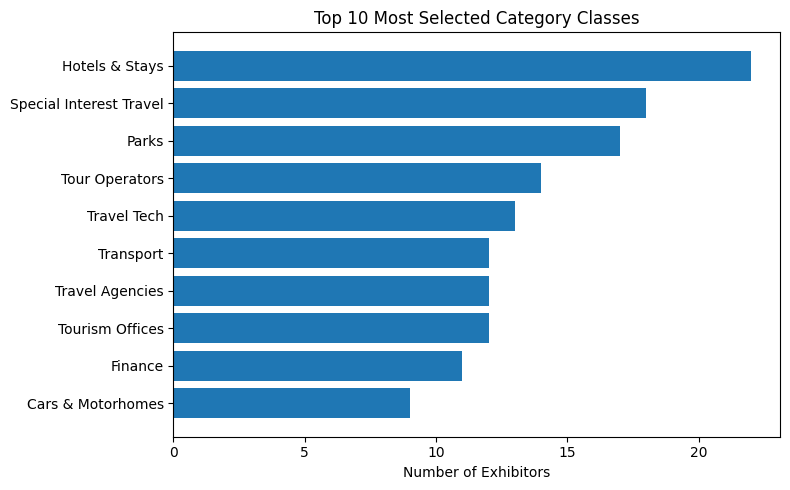

In [88]:
import matplotlib.pyplot as plt

# get top 10 most used category classes
top_classes = category_classes.head(10)

# plot
plt.figure(figsize=(8, 5))
plt.barh(top_classes['category_class_name'], top_classes['count'])

plt.xlabel("Number of Exhibitors")
plt.title("Top 10 Most Selected Category Classes")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()